# Exploratory Data Analysis: India-Focused Credit Risk Dataset

This notebook performs a comprehensive EDA on the `credit_risk_dataset_v3_india_focused.xlsx` dataset containing **6,000 observations** across **17 features** for **100 corporate counterparties** tracked over **60 monthly dates**.

---

## 1. Setup & Data Loading

In [ ]:
# Install dependencies (Colab-friendly)
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')
palette = sns.color_palette('viridis', 10)
sns.set_palette(palette)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
# Load the dataset
df = pd.read_excel('credit_risk_dataset_v3_india_focused.xlsx')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 6,000 rows x 17 columns


,Counterparty_ID,Counterparty_Name,Sector,Region,Type,Date,Interest_Rate (%),FX_Rate (₹/USD),Volatility_Index,Commodity_Price (USD),Credit_Rating,Exposure_INR_Cr,Annual_PD,Monthly_PD,LGD,Expected_Loss_INR_Cr,Default_Flag
0,CP0001,Reliance Industries,Metals,India,Corporate,2020-01-01,6.57,80.3065,8.71,71.57,BBB,1189.72,0.005,0.000418,0.45,0.223585,No
1,CP0001,Reliance Industries,Metals,India,Corporate,2020-02-01,5.85,86.1587,15.24,75.97,BBB,1146.11,0.005,0.000418,0.45,0.215390,No
2,CP0001,Reliance Industries,Metals,India,Corporate,2020-03-01,5.09,81.3815,16.36,69.16,BBB,1150.34,0.005,0.000418,0.45,0.216185,No
3,CP0001,Reliance Industries,Metals,India,Corporate,2020-04-01,6.16,81.2490,21.21,107.17,BBB,1189.13,0.005,0.000418,0.45,0.223474,No
4,CP0001,Reliance Industries,Metals,India,Corporate,2020-05-01,5.71,84.3956,21.73,85.73,BBB,1126.13,0.005,0.000418,0.45,0.211635,No


## 2. Dataset Overview

In [ ]:
# Data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Counterparty_ID        6000 non-null   object        
 1   Counterparty_Name      6000 non-null   object        
 2   Sector                 6000 non-null   object        
 3   Region                 6000 non-null   object        
 4   Type                   6000 non-null   object        
 5   Date                   6000 non-null   datetime64[ns]
 6   Interest_Rate (%)      6000 non-null   float64       
 7   FX_Rate (₹/USD)        6000 non-null   float64       
 8   Volatility_Index       6000 non-null   float64       
 9   Commodity_Price (USD)  6000 non-null   float64       
 10  Credit_Rating          6000 non-null   object        
 11  Exposure_INR_Cr        6000 non-null   float64       
 12  Annual_PD              6000 non-null   float64       
 13  Mon

In [ ]:
# Quick sanity checks
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal nulls: {df.isnull().sum().sum()}')
print(f'\n=== Duplicate Rows ===')
print(f'Duplicates: {df.duplicated().sum()}')
print(f'\n=== Unique Counts ===')
print(df.nunique())

=== Missing Values ===
Counterparty_ID          0
Counterparty_Name        0
Sector                   0
Region                   0
Type                     0
Date                     0
Interest_Rate (%)        0
FX_Rate (₹/USD)          0
Volatility_Index         0
Commodity_Price (USD)    0
Credit_Rating            0
Exposure_INR_Cr          0
Annual_PD                0
Monthly_PD               0
LGD                      0
Expected_Loss_INR_Cr     0
Default_Flag             0
dtype: int64

Total nulls: 0

=== Duplicate Rows ===
Duplicates: 0

=== Unique Counts ===
Counterparty_ID           100
Counterparty_Name         100
Sector                     10
Region                      2
Type                        1
Date                       60
Interest_Rate (%)         619
FX_Rate (₹/USD)          5790
Volatility_Index         2148
Commodity_Price (USD)    3088
Credit_Rating               7
Exposure_INR_Cr          5913
Annual_PD                   7
Monthly_PD                  7
LGD     

In [ ]:
# Summary statistics for numeric columns
df.describe().T.style.format('{:.4f}').background_gradient(cmap='YlOrRd', axis=1)

,count,mean,min,25%,50%,75%,max,std
Date,6000.0000,.4f,.4f,.4f,.4f,.4f,.4f,nan
Interest_Rate (%),6000.0000,4.4986,-0.4900,3.4125,5.2300,5.7500,7.9300,1.8224
FX_Rate (₹/USD),6000.0000,82.5884,72.3961,80.8876,82.6067,84.2775,91.9197,2.5337
Volatility_Index,6000.0000,18.6761,5.0000,14.6000,18.8000,22.7800,43.5300,5.9490
Commodity_Price (USD),6000.0000,77.9713,40.1300,71.3300,77.9500,84.7500,118.1300,10.0513
Exposure_INR_Cr,6000.0000,1415.8346,142.3400,577.3825,959.0150,1618.7525,14258.4600,1685.6098
Annual_PD,6000.0000,0.0281,0.0001,0.0050,0.0150,0.0400,0.1200,0.0384
Monthly_PD,6000.0000,0.0024,0.0000,0.0004,0.0013,0.0034,0.0106,0.0034
LGD,6000.0000,0.4846,0.2000,0.4500,0.5000,0.6000,0.7000,0.1365
Expected_Loss_INR_Cr,6000.0000,1.8506,0.0003,0.0970,0.4654,1.9490,37.2727,3.4211


In [ ]:
# Summary statistics for categorical columns
df.describe(include='object').T

,count,unique,top,freq
Counterparty_ID,6000,100,CP0001,60
Counterparty_Name,6000,100,Reliance Industries,60
Sector,6000,10,Utilities,900
Region,6000,2,India,4500
Type,6000,1,Corporate,6000
Credit_Rating,6000,7,BB,1396
Default_Flag,6000,2,No,5988


## 3. Categorical Feature Analysis

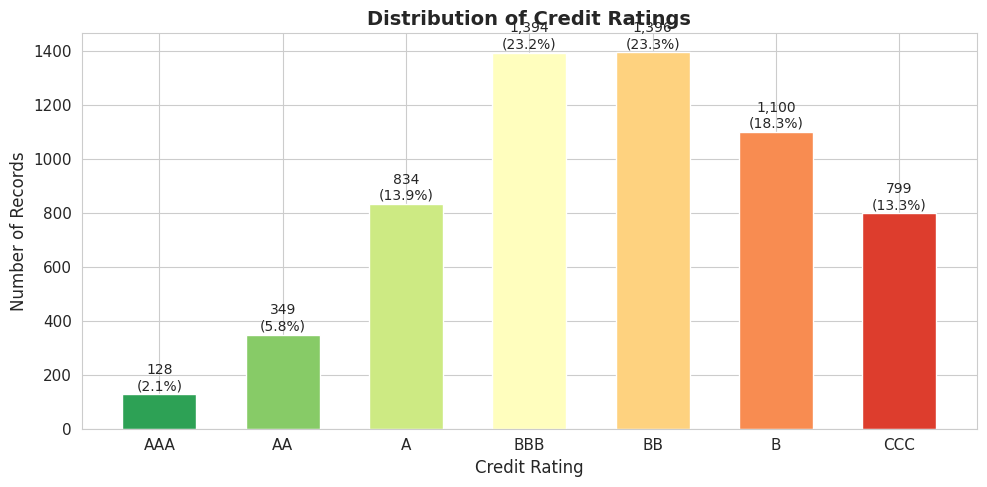

In [ ]:
# Credit Rating distribution
rating_order = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']
rating_counts = df['Credit_Rating'].value_counts().reindex(rating_order)

fig, ax = plt.subplots(figsize=(10, 5))
colors_rating = sns.color_palette('RdYlGn_r', len(rating_order))
bars = ax.bar(rating_order, rating_counts.values, color=colors_rating, edgecolor='white', width=0.6)
ax.set_title('Distribution of Credit Ratings', fontweight='bold')
ax.set_xlabel('Credit Rating')
ax.set_ylabel('Number of Records')

for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

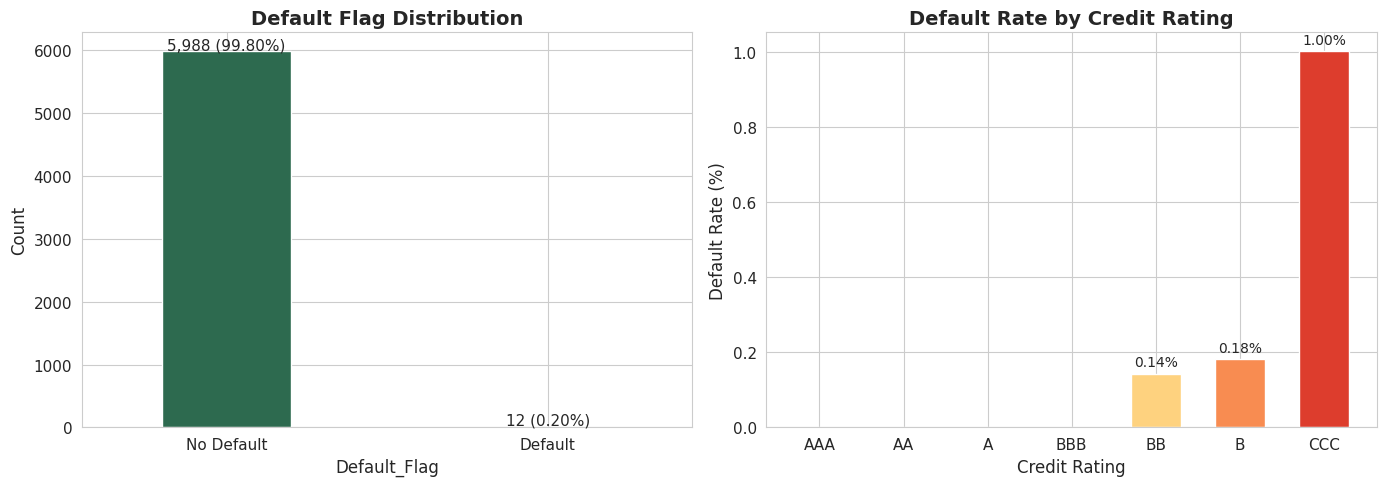


Overall Default Rate: 0.200%
Class Imbalance Ratio (No:Yes): 5988:12 = 499:1


In [ ]:
# Default Flag distribution
default_counts = df['Default_Flag'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

default_colors = ['#2d6a4f', '#e63946']
default_counts.plot(kind='bar', ax=axes[0], color=default_colors, edgecolor='white', width=0.4)
axes[0].set_title('Default Flag Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)
for i, v in enumerate(default_counts.values):
    axes[0].text(i, v + 30, f'{v:,} ({v/len(df)*100:.2f}%)', ha='center', fontsize=11)

# Default rate by credit rating
df_temp = df.copy()
df_temp['Default_Binary'] = (df_temp['Default_Flag'] == 'Yes').astype(int)
default_by_rating = df_temp.groupby('Credit_Rating')['Default_Binary'].mean().reindex(rating_order) * 100

axes[1].bar(default_by_rating.index, default_by_rating.values, color=colors_rating, edgecolor='white', width=0.6)
axes[1].set_title('Default Rate by Credit Rating', fontweight='bold')
axes[1].set_xlabel('Credit Rating')
axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(default_by_rating.values):
    if v > 0:
        axes[1].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'\nOverall Default Rate: {default_counts.get("Yes", 0)/len(df)*100:.3f}%')
print(f'Class Imbalance Ratio (No:Yes): {default_counts["No"]}:{default_counts.get("Yes", 0)} = {default_counts["No"]/max(default_counts.get("Yes", 1), 1):.0f}:1')

## 4. Numerical Feature Distributions

In [ ]:
# Skewness and Kurtosis table
skew_kurt = pd.DataFrame({
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurtosis(),
    'Mean': df[num_cols].mean(),
    'Std Dev': df[num_cols].std(),
    'CV (%)': (df[num_cols].std() / df[num_cols].mean() * 100)
}).round(4)

skew_kurt.style.background_gradient(cmap='coolwarm', subset=['Skewness', 'Kurtosis'])

,Skewness,Kurtosis,Mean,Std Dev,CV (%)
Interest_Rate (%),-0.973600,-0.525500,4.498600,1.822400,40.510200
FX_Rate (₹/USD),-0.018600,0.052600,82.588400,2.533700,3.067900
Volatility_Index,0.027600,-0.198900,18.676100,5.949000,31.853500
Commodity_Price (USD),-0.005500,0.008100,77.971300,10.051300,12.891000
Exposure_INR_Cr,4.247600,22.529200,1415.834600,1685.609800,119.054100
Annual_PD,1.684600,1.437200,0.028100,0.038400,136.638300
Monthly_PD,1.717500,1.522800,0.002400,0.003400,139.327700
LGD,-0.202300,-0.700300,0.484600,0.136500,28.159700
Expected_Loss_INR_Cr,3.725700,20.629900,1.850600,3.421100,184.871100


## 5. Correlation Analysis

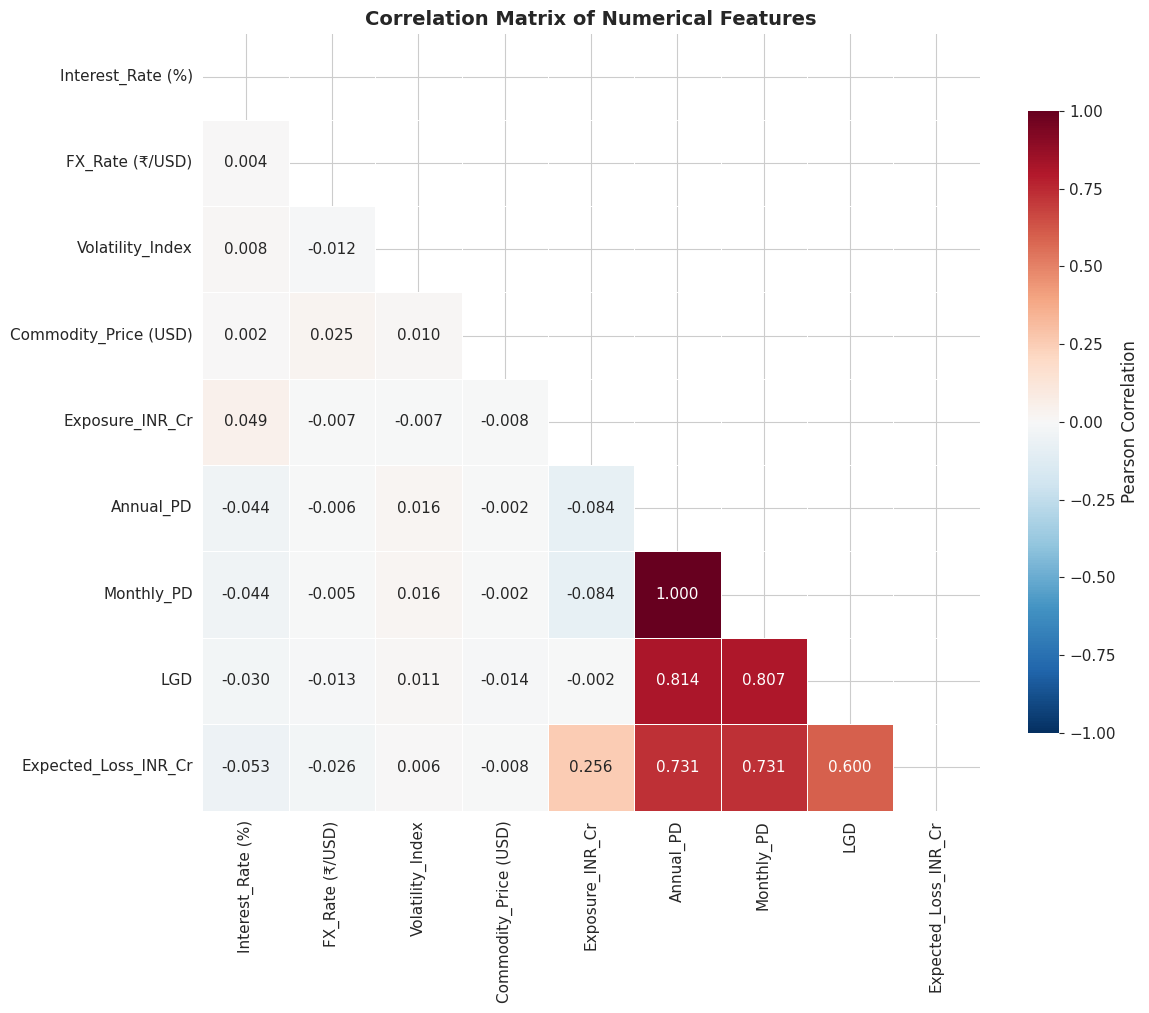

In [ ]:
# Correlation heatmap
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'},
            ax=ax)
ax.set_title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Top correlated feature pairs
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']
corr_pairs = corr_pairs[corr_pairs['Feature_1'] != corr_pairs['Feature_2']]
corr_pairs['Abs_Corr'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.drop_duplicates(subset=['Abs_Corr']).sort_values('Abs_Corr', ascending=False).head(10)

print('Top 10 Correlated Feature Pairs:')
corr_pairs[['Feature_1', 'Feature_2', 'Correlation']].reset_index(drop=True).style.background_gradient(cmap='RdBu_r', subset=['Correlation'], vmin=-1, vmax=1)

Top 10 Correlated Feature Pairs:


,Feature_1,Feature_2,Correlation
0,Annual_PD,Monthly_PD,0.999898
1,Annual_PD,LGD,0.813796
2,Monthly_PD,LGD,0.807408
3,Annual_PD,Expected_Loss_INR_Cr,0.731255
4,Monthly_PD,Expected_Loss_INR_Cr,0.731082
5,LGD,Expected_Loss_INR_Cr,0.599999
6,Exposure_INR_Cr,Expected_Loss_INR_Cr,0.255761
7,Exposure_INR_Cr,Monthly_PD,-0.084255
8,Exposure_INR_Cr,Annual_PD,-0.083843
9,Interest_Rate (%),Expected_Loss_INR_Cr,-0.053103


## 6. Default Analysis Deep Dive

In [ ]:
# Profile of defaulted vs non-defaulted records
df_compare = df.copy()
df_compare['Default_Binary'] = (df_compare['Default_Flag'] == 'Yes').astype(int)

default_profile = df_compare.groupby('Default_Flag')[num_cols].mean().T
default_profile['Diff (%)'] = ((default_profile.get('Yes', 0) - default_profile['No']) / default_profile['No'] * 100)
default_profile.style.format('{:.4f}').background_gradient(cmap='RdYlGn_r', subset=['Diff (%)'])

Default_Flag,No,Yes,Diff (%)
Interest_Rate (%),4.4985,4.5300,0.6997
FX_Rate (₹/USD),82.5881,82.7194,0.1590
Volatility_Index,18.6781,17.6650,-5.4241
Commodity_Price (USD),77.9721,77.5683,-0.5179
Exposure_INR_Cr,1416.5627,1052.5158,-25.6993
Annual_PD,0.0280,0.0892,218.3056
Monthly_PD,0.0024,0.0078,223.0410
LGD,0.4843,0.6500,34.2207
Expected_Loss_INR_Cr,1.8417,6.2506,239.3855


In [ ]:
# Characteristics of defaulted counterparties
defaults = df[df['Default_Flag'] == 'Yes']
if len(defaults) > 0:
    print(f'Total default records: {len(defaults)}')
    print(f'\nDefaulted Counterparties:')
    print(defaults[['Counterparty_Name', 'Sector', 'Region', 'Credit_Rating',
                     'Exposure_INR_Cr', 'Annual_PD', 'LGD', 'Expected_Loss_INR_Cr']].to_string(index=False))

    print(f'\n--- Defaults by Sector ---')
    print(defaults['Sector'].value_counts())
    print(f'\n--- Defaults by Credit Rating ---')
    print(defaults['Credit_Rating'].value_counts())
    print(f'\n--- Defaults by Region ---')
    print(defaults['Region'].value_counts())
else:
    print('No default events in dataset.')

Total default records: 12

Defaulted Counterparties:
  Counterparty_Name         Sector        Region Credit_Rating  Exposure_INR_Cr  Annual_PD  LGD  Expected_Loss_INR_Cr
         Indian Oil Infrastructure         India           CCC          1934.58      0.120  0.7             14.349493
      Bajaj Finance      Utilities         India           CCC          1376.19      0.120  0.7             10.207709
          TVS Motor         Metals         India           CCC           433.78      0.120  0.7              3.217506
         Zomato Ltd    Real Estate         India            BB           975.73      0.015  0.5              0.614064
      Tata Consumer Infrastructure         India             B           572.02      0.040  0.6              1.165566
      Philips India      Transport         India           CCC           382.18      0.120  0.7              2.834770
      Philips India      Transport         India             B           369.19      0.040  0.6              0.752273
Tat

## 7. Key Findings Summary

EDA SUMMARY - India-Focused Credit Risk Dataset


DATASET OVERVIEW:
  - 6000 records , 17 features , 0 missing values
  - 100 unique counterparties across 60 time periods
  - 10 sectors , 2 regions , 7 credit ratings

PORTFOLIO COMPOSITION:
  - Region split: India 75% , International 25%
  - Largest sector: Utilities (900 records)
  - Most common rating: BB (1,396 records)
  - All counterparties are Corporate type

RISK METRICS:
  - Avg Exposure: INR 1415.83 Cr (Median: 959.01 Cr)
  - Avg Expected Loss: INR 1.8506 Cr
  - Avg Annual PD: 2.81% | Avg LGD: 48.5%
  - Exposure is right-skewed (mean >> median)

DEFAULTS:
  - Default rate: 0.200% (12 defaults out of 6,000)
  - Highly imbalanced target variable